# Datasets: catalogue, overlap map, cleaning audit, EDA and splits

Every **available** MI-coded or MI-domain dataset in this project, under one canonical
name each. Logic lives in `src/eda/` (`registry`, `overlap`, `clean`, `splits`, `stats`).
This notebook only calls it and shows the results. The static summary is
[`docs/DATASETS.md`](../docs/DATASETS.md).

**Run:** `jupyter nbconvert --to notebook --execute --inplace notebooks/datasets_eda.ipynb`
(from the repo root). The AnnoMI and Welivita releases download to
`data/external/` on first run. CASAA must be parsed first (`python -m baseline.prep_casaa`).

**Reading guide:** §1 naming → §2 catalogue → §3 coding schemes → **§4 overlap map** →
§5 cleaning audit → §6 per-dataset EDA → §7 cross-dataset → §8 splits → §9 checks.

Real datasets only. Our generated sets are in `notebooks/synthetic_eda.ipynb` / `docs/SYNTHETIC_DATA.md`.

*CASAA transcripts are third-party training material, so only aggregates are shown for them, never utterance text.*

In [1]:
import os, sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src')); os.chdir(ROOT)
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from eda import registry, overlap, clean, splits, stats
pd.set_option('display.max_colwidth', 120); pd.set_option('display.max_rows', 200); pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', font_scale=0.9)
registry.ensure_downloads()
F = registry.load_all()
GOLD = ['misc.miv63a.gold', 'misc.hlqc.gold', 'annomi.gold', 'welivita.gold', 'miti.casaa.gold']
POOLS = ['pool.hlqc', 'pool.miv63a', 'pool.miv63b']
print({k: len(v) for k, v in F.items()})

{'misc.miv63a.gold': 821, 'misc.hlqc.gold': 1925, 'pool.hlqc': 30610, 'pool.miv63a': 13692, 'pool.miv63b': 11771, 'annomi.gold': 9699, 'welivita.gold': 20462, 'miti.casaa.gold': 1346}


## 1. Naming: file → canonical ID → what it really is
The same corpus sits in several files with unrelated names. Two traps:
- `HLQC.csv` and `HLQC_parsed.csv` are the unlabelled pool, while `HLQC_balanced_manual.csv` is the 10-session gold training set.
- `data/AnnoMI.csv` is AutoMISC's MISC-mapped copy, in a different row order from the official release.

In [2]:
naming = pd.DataFrame([{'canonical_id': m.id, 'file': f, 'what it is': d}
                       for m in registry.META.values() if m.id in F for f, d in m.files.items()])
naming

,canonical_id,file,what it is
0,misc.miv63a.gold,data/manual/MIV6.3A_manual.csv,"10 sessions, utterance-segmented, *_GT = human consensus, *_auto = AutoMISC GPT-4.1"
1,misc.hlqc.gold,data/manual/HLQC_balanced_manual.csv,"10 sessions (5 high, 5 low), utterance-segmented, *_GT human"
2,pool.hlqc,data/HLQC.csv,"257 sessions, volley level (one row per speaker turn)"
3,pool.hlqc,data/parsed/HLQC_parsed.csv,"same 257 sessions, split into utterances by the AutoMISC parser"
4,pool.miv63a,data/MIV6.3A.csv,"173 sessions, volley level"
5,pool.miv63a,data/parsed/MIV6.3A_parsed.csv,utterance level
6,pool.miv63a,data/2024-11-14-MIV6.3A-...merged.csv,per-participant readiness/importance/confidence pre/post/week-later + demographics (join on 'Participant id' = conv_id)
7,pool.miv63b,data/MIV6.3B.csv,"165 sessions, volley level"
8,pool.miv63b,data/parsed/MIV6.3B_parsed.csv,utterance level
9,pool.miv63b,data/2024-11-19-MIV6.1B_...merged.csv,outcomes file (named 6.1B; verify it is this run)


## 2. Catalogue: metadata per dataset

In [3]:
fields = ['title','domain','modality','transcription','session_type','language','scheme','unit',
          'annotators','reliability','licence','source','role','lineage']
cat = pd.DataFrame([{**{'id': m.id}, **{f: getattr(m, f) for f in fields},
                     'known_issues': '; '.join(m.known_issues)} for m in registry.META.values() if m.id in F]).set_index('id')
size = pd.DataFrame({k: stats.structure(v) for k, v in F.items()}).T[['conversations','rows (units)','counsellor rows','client rows','coded rows','MISC T2 rows']]
cat.join(size)

,title,domain,modality,transcription,session_type,language,scheme,unit,annotators,reliability,...,source,role,lineage,known_issues,conversations,rows (units),counsellor rows,client rows,coded rows,MISC T2 rows
id,,,,,,,,,,,,,,,,,,,,,
misc.miv63a.gold,"MIBot v6.3A, expert MISC consensus (TEST SET)",smoking cessation,"chatbot text (LLM counsellor, human client)",none (typed),real participants (Prolific) with MIBot v6.3A,English,"MISC 2.5 + AutoMISC extension (Activation AC+/-; AutoMISC T1 grouping), both speakers","utterance (thought unit), single label","4 trained coders, consensus",Fleiss kappa >= 0.6 after alignment (thesis App. B),...,https://github.com/cimhasgithub/AutoMISC,fixed test set for all MISC models,10 of the 173 pool.miv63a sessions; labels by 3 interns + 1 grad student aligned to MI clinicians (AutoMISC thesis).,"only 10 sessions, no dev split; TS+ / AC- occur here but not in HLQC train",10,821,580,241,821,821
misc.hlqc.gold,"HLQC balanced subset, MISC 2.5 (TRAIN SET)","mixed health behaviour (alcohol, diet, exercise, smoking, ...)","spoken, transcribed","ASR (Pérez-Rosas et al. 2019), no casing/punctuation",MI demonstration / role-play videos,English,"MISC 2.5 + AutoMISC extension (Activation AC+/-; AutoMISC T1 grouping), both speakers","utterance, single label",AutoMISC team,not reported for this subset,...,https://github.com/cimhasgithub/AutoMISC,training set for all MISC models; few-shot / synthesis exemplars,10 of the 257 pool.hlqc sessions; labels by the AutoMISC team (released with NLPAI4Health 2025).,"FI vs FA coded inconsistently; noisy ASR text; 1,925 rows vs 1,924 in the paper; high_121 = CASAA 'Emmy's First Enco...",10,1925,1040,885,1925,1925
pool.hlqc,HLQC full corpus (UNLABELLED pool),mixed health behaviour,"spoken, transcribed",ASR,MI demonstration videos (YouTube/Vimeo),English,none at utterance level (session high/low quality only),volley / utterance,-,-,...,Pérez-Rosas et al. 2019,"unlabelled pool (retrieval, self-training); contains misc.hlqc.gold",Pérez-Rosas et al. 2019 'What makes a good counselor?'; session id prefix high_/low_ = session-level quality label.,contains the 10 gold sessions; MI-TAGS authors report duplicate / mismatched transcripts,257,30610,15898,14712,0,0
pool.miv63a,MIBot v6.3A full run (UNLABELLED pool),smoking cessation,chatbot text,none,real participants with MIBot,English,none,volley / utterance,-,-,...,https://github.com/cimhasgithub/AutoMISC,unlabelled pool; MUST exclude the 10 test sessions,MIBot v6.3A study (Mahmood et al. 2025); contains the 10 misc.miv63a.gold sessions.,contains the test set; templated chatbot lines repeat across sessions,173,13692,9835,3857,0,0
pool.miv63b,MIBot v6.3B run (UNLABELLED pool),smoking cessation,chatbot text,none,real participants with MIBot,English,none,volley / utterance,-,-,...,https://github.com/cimhasgithub/AutoMISC,unlabelled pool (self-training v2 'Step F'),A different MIBot run from 6.3A (different participants).,shares templated chatbot utterances with the MIV6.3A test set (22/652 long test utts verbatim),165,11771,6844,4927,0,0
annomi.gold,AnnoMI (expert-annotated MI demonstrations),"mixed (alcohol, smoking, diet, ...); 'topic' column","spoken, transcribed",manual (professional),"MI demonstrations (110 high, 23 low quality)",English,AnnoMI: therapist main behaviour + subtypes; client change/neutral/sustain,speaker turn,"10 MI experts; 126 transcripts single-annotated, 7 by all 10",paper: none per item; measured by us (notebook),...,https://github.com/uccollab/AnnoMI,own-scheme train/dev/test; cross-scheme transfer test for MISC models,"Wu et al. 2022/2023; 133 YouTube/Vimeo demonstrations, professionally transcribed.",strong annotator effect (complex-reflection share 0.19-0.82 on the same items); client-talk kappa 0.47; may overlap ...,133,9699,4882,4817,9699,2628
welivita.gold,Welivita & Pu MI dataset (peer-support forums),mental-health peer support (written),written forum Q&A,none,online forum threads (2-6 turns),English,"

## 3. Coding schemes: handbook codes, our vocabulary, and data coverage
Code lists are transcribed from the **handbooks**, not derived from the data, so a class that no
dataset contains still appears:
- MISC 2.5 (Houck et al. 2010; counsellor p.16, client pp.38-41, No Code p.14);
- MITI 4.2.1 (Moyers et al. 2015);
- Welivita & Pu 2022, Table 1;
- AnnoMI (Wu et al. 2023, Sec. 4).

`handbook_check` marks each code as present in our vocabulary or not, flags our extensions, and
lists the datasets with examples. **An empty `datasets_with_examples` cell is a real class we have no
data for.**

In [4]:
H = registry.handbook_check(F)
ab = {'misc.hlqc.gold':'HLQC','misc.miv63a.gold':'MIV','miti.casaa.gold':'CASAA','welivita.gold':'Welivita','annomi.gold':'AnnoMI'}
H['gold datasets'] = H.datasets_with_examples.map(lambda s: ', '.join(ab[x.strip()] for x in s.split(',') if x.strip() in ab))
H[['scheme','speaker','code','manual_group','status','gold datasets']]

,scheme,speaker,code,manual_group,status,gold datasets
0,MISC 2.5,counsellor,ADP,MICO,ok,"HLQC, MIV"
1,MISC 2.5,counsellor,ADW,MIIN,ok,HLQC
2,MISC 2.5,counsellor,AF,MICO,ok,"HLQC, MIV"
3,MISC 2.5,counsellor,CO,MIIN,ok,HLQC
4,MISC 2.5,counsellor,DI,MIIN,ok,"HLQC, MIV"
5,MISC 2.5,counsellor,EC,MICO,ok,"HLQC, MIV"
6,MISC 2.5,counsellor,FA,neither,ok,"HLQC, MIV"
7,MISC 2.5,counsellor,FI,neither,ok,"HLQC, MIV"
8,MISC 2.5,counsellor,GI,neither,ok,"HLQC, MIV"
9,MISC 2.5,counsellor,OQ,MICO,ok,"HLQC, MIV"


In [5]:
print('Handbook classes with NO real gold example:')
display(H[(H.status == 'ok') & (H['gold datasets'] == '')][['scheme','speaker','code']])
print('Our codes that are NOT in the handbook:'); display(H[H.status.str.startswith(('extension', 'in data'))][['scheme','code','status']])
print('MISC 2.5 handbook notes:', registry.HANDBOOK['MISC 2.5']['notes'])
print('MISC 2.5 global ratings (not in our data):', registry.HANDBOOK['MISC 2.5']['globals'])
print('MITI 4.2.1 global ratings:', registry.HANDBOOK['MITI 4.2.1']['globals'], '(CASAA has them for 9 sessions)')

Handbook classes with NO real gold example:


,scheme,speaker,code
11,MISC 2.5,counsellor,RCP
31,MISC 2.5,client,TS-


Our codes that are NOT in the handbook:


,scheme,code,status
35,MISC 2.5,AC+,"extension (not in handbook): AutoMISC addition (Activation; thesis footnote 1 cites Miller & Rollnick, Motivational ..."
36,MISC 2.5,AC-,extension (not in handbook): AutoMISC addition (Activation-); not in MISC 2.5.
47,MITI 4.2.1,NC,"in data, not in handbook (CASAA transcript convention)"
48,MITI 4.2.1,SAME,"in data, not in handbook (CASAA transcript convention)"


MISC 2.5 handbook notes: SR/CR require a valence (+/-/0/+-) in the manual; Ask is part of Follow/Neutral (FN).
MISC 2.5 global ratings (not in our data): ['Acceptance', 'Empathy', 'Direction', 'Autonomy Support', 'Collaboration', 'Evocation', 'Self-Exploration (client)']
MITI 4.2.1 global ratings: ['Cultivating Change Talk', 'Softening Sustain Talk', 'Partnership', 'Empathy'] (CASAA has them for 9 sessions)


### 3b. Each scheme's codes with the MISC crosswalk
MISC 2.5 is our target scheme. Each of the other schemes maps to MISC **only where the concepts
are identical** (`exact`); some map only at the group level (`T1 only`), and the rest have no MISC
equivalent (`none`). Our six counsellor T1 groups (CRL, SRL, IMC, IMI, Q, O) are AutoMISC's own
grouping by semantic similarity. The manual's own groups are MICO and MIIN.

In [6]:
S = registry.schemes()
for name, t in S.items():
    print(f'=== {name}: {len(t)} codes'); display(t)

=== MISC 2.5: 37 codes


,speaker,code,our_t1 (AutoMISC grouping),manual_group,source
0,counsellor,ADP,IMC,MICO,MISC 2.5 p.16
1,counsellor,ADW,IMI,MIIN,MISC 2.5 p.16
2,counsellor,AF,CRL,MICO,MISC 2.5 p.16
3,counsellor,CO,IMI,MIIN,MISC 2.5 p.16
4,counsellor,DI,IMI,MIIN,MISC 2.5 p.16
5,counsellor,EC,CRL,MICO,MISC 2.5 p.16
6,counsellor,FA,O,neither,MISC 2.5 p.16
7,counsellor,FI,O,neither,MISC 2.5 p.16
8,counsellor,GI,IMC,neither,MISC 2.5 p.16
9,counsellor,OQ,Q,MICO,MISC 2.5 p.16


=== MITI 4.2.1 (CASAA): 12 codes


,code,meaning,misc_t1,misc_t2,mapping,source
0,GI,Giving information,IMC,GI,exact,MITI 4.2.1
1,Persuade,Persuade,None,None,none,MITI 4.2.1
2,Persuade with Permission,Persuade with permission,None,None,none,MITI 4.2.1
3,Q,Question (open/closed not split),Q,None,T1 only,MITI 4.2.1
4,SR,Simple reflection,SRL,SR,exact,MITI 4.2.1
5,CR,Complex reflection,CRL,CR,exact,MITI 4.2.1
6,AF,Affirm,CRL,AF,exact,MITI 4.2.1
7,Seek,Seeking collaboration,None,None,none,MITI 4.2.1
8,Emphasize,Emphasizing autonomy,CRL,EC,exact,MITI 4.2.1
9,Confront,Confront,IMI,CO,exact,MITI 4.2.1


=== Welivita MITI-derived: 15 codes


,code,misc_t2,misc_t1,mapping,source
0,Closed Question,CQ,Q,exact,Welivita & Pu 2022 Table 1
1,Open Question,OQ,Q,exact,Welivita & Pu 2022 Table 1
2,Simple Reflection,SR,SRL,exact,Welivita & Pu 2022 Table 1
3,Complex Reflection,CR,CRL,exact,Welivita & Pu 2022 Table 1
4,Give Information,GI,IMC,exact,Welivita & Pu 2022 Table 1
5,Advise with Permission,ADP,IMC,exact,Welivita & Pu 2022 Table 1
6,Affirm,AF,CRL,exact,Welivita & Pu 2022 Table 1
7,Emphasize Autonomy,EC,CRL,exact,Welivita & Pu 2022 Table 1
8,Support,SU,CRL,exact,Welivita & Pu 2022 Table 1
9,Advise without Permission,ADW,IMI,exact,Welivita & Pu 2022 Table 1


=== AnnoMI: 12 codes


,speaker,attribute,subtype,misc,mapping
0,therapist,question,open,OQ,exact
1,therapist,question,closed,CQ,exact
2,therapist,reflection,simple,SR,exact
3,therapist,reflection,complex,CR,exact
4,therapist,input,information,GI,exact
5,therapist,input,advice,ADP/ADW,permission unknown
6,therapist,input,negotiation/goal-setting,None,none
7,therapist,input,options,None,none
8,therapist,other (main behaviour),None,None,none
9,client,change,None,C (T1),T1 only


In [7]:
from synth.codes import codebook
print(codebook()[:6000])  # MISC 2.5 definitions as used in our prompts

### COUNSELLOR codes (Tier-1 group -> Tier-2 codes)
[CRL]
- **Complex Reflection (CR)**: A reflective listening statement that adds significant meaning or emphasis to what the client said, conveying a deeper or richer picture of the client's statement.
- **Affirm (AF)**: Communicates something positive or complimentary about the client's strengths or efforts.
- **Support (SU)**: Sympathetic, compassionate, or understanding comments, which agree or side with the client.
- **Reframe (RF)**: Suggests a different meaning for an experience expressed by the client, usually changing the emotional valence of meaning but not the depth.
- **Emphasize Control (EC)**: Acknowledges, honours, or emphasizes the client's autonomy and freedom of choice.

[SRL]
- **Simple Reflection (SR)**: A reflective listening statement which simply repeats or paraphrases the client's words or meaning, often with a slight change in wording or emphasis.

[IMC]
- **Advise With Permission (ADP)**: After receiving permis

## 4. Overlap map: which dataset overlaps which
Three relation types:
- **subset**: a gold file is a labelled slice of a pool (same session ids).
- **derived**: the same data in another file format.
- **duplicate**: the *same session under different ids in different corpora*. These were found by 5-gram containment over conversations: shingles shared ÷ shingles in the smaller conversation, ignoring shingles that occur in more than 5 conversations. Unrelated sessions score about 0.00–0.02. Manual-vs-ASR copies of one video score 0.13–0.95.

In [8]:
print('Known by construction:'); display(overlap.known_relations(F))
P = overlap.pairwise(F)
dup = P[(P.containment >= 0.10) & (P.conv_a != P.conv_b)]
print(f'{len(dup)} duplicate session pairs (containment >= 0.10)')

Known by construction:


,dataset_a,dataset_b,relation,detail,verified
0,misc.hlqc.gold,pool.hlqc,subset,the 10 gold sessions are pool sessions (same conv_id),10/10 misc.hlqc.gold sessions found in pool.hlqc
1,misc.miv63a.gold,pool.miv63a,subset,the 10 test sessions are pool sessions (same conv_id),10/10 misc.miv63a.gold sessions found in pool.miv63a
2,annomi.gold,annomi.gold,derived,AnnoMI-full -> AnnoMI-simple -> data/AnnoMI.csv (AutoMISC MISC map) -> data/manual/AnnoMI_eval.csv; parsed/AnnoMI_pa...,
3,welivita.gold,welivita.gold,derived,release MI_Dataset.csv -> external/welivita_mi_parsed.csv -> manual/Welivita_eval.csv; selftrain pseudo-labels are m...,


490 duplicate session pairs (containment >= 0.10)


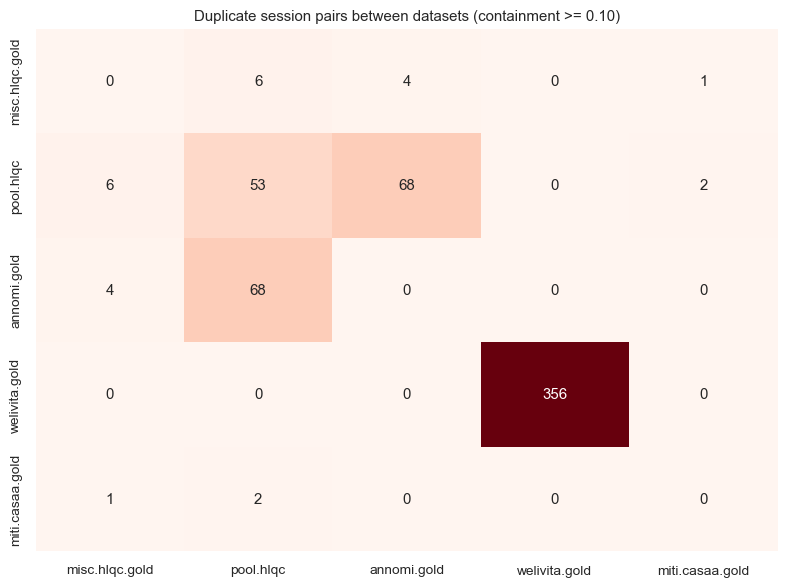

In [9]:
# dataset x dataset: number of duplicate session pairs
ids = list(F)
M = pd.DataFrame(0, index=ids, columns=ids)
for a, b in zip(dup.dataset_a, dup.dataset_b):
    M.loc[a, b] += 1
    if a != b: M.loc[b, a] += 1
keep = M.index[(M.sum(1) > 0)]
plt.figure(figsize=(8, 6)); sns.heatmap(M.loc[keep, keep], annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Duplicate session pairs between datasets (containment >= 0.10)'); plt.tight_layout(); plt.show()

In [10]:
def show_pairs(a, b, thr=0.10):
    x = dup[((dup.dataset_a == a) & (dup.dataset_b == b)) | ((dup.dataset_a == b) & (dup.dataset_b == a))]
    return x[x.containment >= thr][['dataset_a','conv_a','dataset_b','conv_b','containment']].reset_index(drop=True)
print('HLQC GOLD (our TRAIN set) duplicated elsewhere:')
for other in ['annomi.gold', 'miti.casaa.gold', 'pool.hlqc']:
    t = show_pairs('misc.hlqc.gold', other); t = t[t.conv_a != t.conv_b]
    print(f'  vs {other}: {len(t)}'); display(t)

HLQC GOLD (our TRAIN set) duplicated elsewhere:
  vs annomi.gold: 4


,dataset_a,conv_a,dataset_b,conv_b,containment
0,annomi.gold,53,misc.hlqc.gold,low_001,0.692
1,annomi.gold,15,misc.hlqc.gold,low_080,0.668
2,annomi.gold,21,misc.hlqc.gold,high_099,0.663
3,annomi.gold,44,misc.hlqc.gold,low_033,0.618


  vs miti.casaa.gold: 1


,dataset_a,conv_a,dataset_b,conv_b,containment
0,misc.hlqc.gold,high_121,miti.casaa.gold,casaa_emmys-first-encounter,0.397


  vs pool.hlqc: 6


,dataset_a,conv_a,dataset_b,conv_b,containment
0,misc.hlqc.gold,low_026,pool.hlqc,high_084,0.949
1,misc.hlqc.gold,low_001,pool.hlqc,low_027,0.930
2,misc.hlqc.gold,low_001,pool.hlqc,low_040,0.901
3,misc.hlqc.gold,low_080,pool.hlqc,low_019,0.874
4,misc.hlqc.gold,low_031,pool.hlqc,low_054,0.821
5,misc.hlqc.gold,low_080,pool.hlqc,low_098,0.595


In [11]:
print('MIV6.3A GOLD (TEST set) duplicated elsewhere (excluding its own pool rows):')
t = dup[(dup.dataset_a.eq('misc.miv63a.gold') | dup.dataset_b.eq('misc.miv63a.gold'))]
display(t[t.conv_a != t.conv_b])
print('AnnoMI transcripts that are also HLQC pool sessions:', show_pairs('annomi.gold', 'pool.hlqc').shape[0])
display(show_pairs('annomi.gold', 'pool.hlqc').head(15))

MIV6.3A GOLD (TEST set) duplicated elsewhere (excluding its own pool rows):


,dataset_a,conv_a,dataset_b,conv_b,shared_shingles,containment,size_a,size_b


AnnoMI transcripts that are also HLQC pool sessions: 68


,dataset_a,conv_a,dataset_b,conv_b,containment
0,annomi.gold,126,pool.hlqc,low_067,0.851
1,annomi.gold,106,pool.hlqc,low_099,0.848
2,annomi.gold,69,pool.hlqc,low_069,0.840
3,annomi.gold,123,pool.hlqc,low_083,0.831
4,annomi.gold,113,pool.hlqc,high_041,0.822
5,annomi.gold,123,pool.hlqc,low_024,0.822
6,annomi.gold,106,pool.hlqc,low_065,0.816
7,annomi.gold,113,pool.hlqc,high_080,0.809
8,annomi.gold,123,pool.hlqc,low_097,0.804
9,annomi.gold,130,pool.hlqc,low_059,0.795


In [12]:
print('Within-corpus duplicates:')
for d in ['pool.hlqc', 'annomi.gold', 'welivita.gold']:
    print(f'  {d}: {show_pairs(d, d).shape[0]} pairs >= 0.10, {show_pairs(d, d, 0.5).shape[0]} pairs >= 0.50')


Within-corpus duplicates:
  pool.hlqc: 53 pairs >= 0.10, 51 pairs >= 0.50
  annomi.gold: 0 pairs >= 0.10, 0 pairs >= 0.50
  welivita.gold: 356 pairs >= 0.10, 48 pairs >= 0.50


In [13]:
ov = overlap.summarise(P, F)
ov  # the full dataset-pair summary that docs/DATASETS.md reproduces

,dataset_a,dataset_b,n_pairs,sessions
0,annomi.gold,misc.hlqc.gold,4,53=low_001 (0.69); 15=low_080 (0.67); 21=high_099 (0.66); 44=low_033 (0.62)
1,annomi.gold,pool.hlqc,68,126=low_067 (0.85); 106=low_099 (0.85); 69=low_069 (0.84); 123=low_083 (0.83); 113=high_041 (0.82); 123=low_024 (0.8...
2,misc.hlqc.gold,miti.casaa.gold,1,high_121=casaa_emmys-first-encounter (0.40)
3,misc.hlqc.gold,pool.hlqc,6,low_026=high_084 (0.95); low_001=low_027 (0.93); low_001=low_040 (0.90); low_080=low_019 (0.87); low_031=low_054 (0....
4,miti.casaa.gold,pool.hlqc,2,casaa_emmys-first-encounter=high_121 (0.40); casaa_rounder-miti-4=high_072 (0.28)
5,pool.hlqc,pool.hlqc,53,low_003=low_005 (1.00); low_008=low_048 (1.00); high_011=high_014 (0.98); low_028=low_081 (0.98); high_016=high_085 ...
6,welivita.gold,welivita.gold,356,counsel_chat | 100=counsel_chat | 1857 (1.00); counsel_chat | 1856=counsel_chat | 99 (1.00); counsel_chat | 182=coun...


## 5. Cleaning / processing audit
Nothing here edits a data file. Each row says whether the issue
- needs no action,
- is handled downstream already,
- is handled by an exclusion list in `data/splits/`, or
- needs a decision.

In [14]:
A = clean.run(F, P)
A.loc[A.dataset == 'miti.casaa.gold', 'example'] = ''   # no CASAA text in outputs
A[(A.n > 0) | (A.severity != 'info')].reset_index(drop=True)

,dataset,check,n,share,example,severity,action
0,misc.miv63a.gold,no casing (ASR signal),125,0.1523,,info,expected for ASR corpora
1,misc.miv63a.gold,no punctuation (ASR signal),118,0.1437,,info,expected for ASR corpora
2,misc.miv63a.gold,short utterances (>=3 occurrences) with conflicting T2,1,0.1429,'great',warn,"annotation noise: report, do not relabel"
3,misc.hlqc.gold,consecutive identical utterances (same speaker),6,0.0031,['yeah'],info,inspect
4,misc.hlqc.gold,no casing (ASR signal),1107,0.5751,,info,expected for ASR corpora
5,misc.hlqc.gold,no punctuation (ASR signal),1531,0.7953,,info,expected for ASR corpora
6,misc.hlqc.gold,T1 inconsistent with T2 group,6,0.0031,Q/ST,error,fix in derived copy
7,misc.hlqc.gold,short utterances (>=3 occurrences) with conflicting T2,9,0.3333,"'okay', 'yeah', 'mmhmm'",warn,"annotation noise: report, do not relabel"
8,pool.hlqc,consecutive identical utterances (same speaker),76,0.0025,['thank you'],info,inspect
9,pool.hlqc,no casing (ASR signal),17829,0.5825,,info,expected for ASR corpora


In [15]:
t1_of = clean.misc_vocab()
h = F['misc.hlqc.gold']
bad = h[[t1_of.get((s, c)) not in (None, t) for s, c, t in zip(h.speaker, h.t2, h.t1)]]
print('HLQC gold rows whose T1 contradicts the T2 group (training labels; needs a decision):')
bad[['conv_id','utt_idx','speaker','text','t1','t2']]

HLQC gold rows whose T1 contradicts the T2 group (training labels; needs a decision):


,conv_id,utt_idx,speaker,text,t1,t2
453,high_117,142,counsellor,so how does that sound to you?,Q,ST
604,high_121,120,counsellor,"I just wanna say we, we can go over some things that are potential to talk about to really focus on that might help ...",CRL,ST
809,high_127,7,counsellor,so let's talk more about what brought you in today,O,OQ
1523,low_031,156,counsellor,tell me a little bit about those,O,OQ
1546,low_031,179,counsellor,where would you put yourself on how important this is to you,O,CQ
1547,low_031,180,counsellor,want to say on a scale of one to ten just just on importance,O,CQ


## 6. Per-dataset EDA

In [16]:
def eda(ds, col_native=True, text=True):
    df = F[ds]
    print(f'##### {ds}'); display(pd.Series(stats.structure(df), name=ds).to_frame())
    if text: display(pd.Series(stats.text_quality(df), name='text quality').round(3).to_frame())
    for col in (['native'] if col_native else []) + ['t2', 't1']:
        lt = stats.label_table(df, col)
        if lt.empty: continue
        fig, ax = plt.subplots(1, lt.speaker.nunique(), figsize=(12, 3.2), squeeze=False)
        for i, (spk, g) in enumerate(lt.groupby('speaker')):
            g = g.sort_values('n', ascending=False)
            ax[0, i].bar(g.code, g.n, color=['#c44' if t else '#48a' for t in g['is_tail']])
            ax[0, i].set_yscale('log'); ax[0, i].set_title(f'{ds} {col} - {spk} (red = tail)')
            ax[0, i].tick_params(axis='x', rotation=70, labelsize=7)
        plt.tight_layout(); plt.show()
        print(f'{col}: tail codes =', lt[lt['is_tail']].groupby('speaker').code.apply(list).to_dict())
    pp = stats.position_profile(df, 't1')
    if len(pp):
        plt.figure(figsize=(9, 2.8)); sns.heatmap(pp.T, cmap='Blues', cbar=False)
        plt.title(f'{ds}: T1 share by session-position decile'); plt.tight_layout(); plt.show()

### 6.1 `misc.miv63a.gold`: MIBot v6.3A expert MISC (TEST)

##### misc.miv63a.gold


,misc.miv63a.gold
conversations,10
rows (units),821
counsellor rows,580
client rows,241
units / conv (median),78.5
units / conv (min-max),37-119
turns / conv (median),32.5
words / unit (median),12.0
words / unit (p95),25.0
coded rows,821


,text quality
has uppercase,0.848
has sentence punctuation,0.826
contains filler (um/uh/mm-hmm/you know),0.004
type-token ratio (5k-word sample),0.243


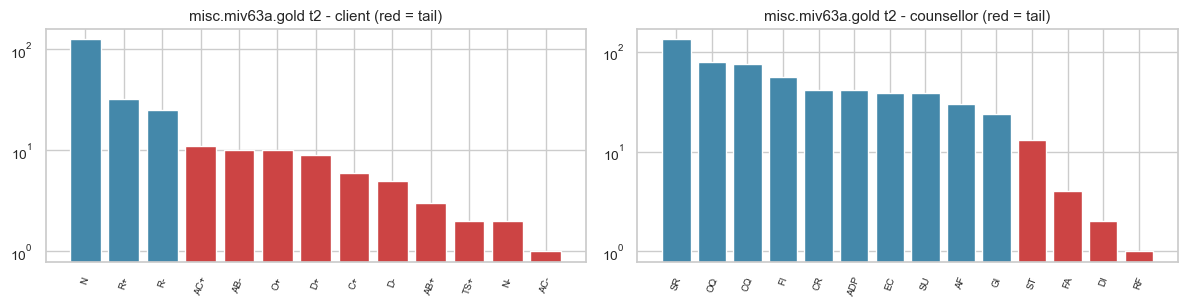

t2: tail codes = {'client': ['AC+', 'AB-', 'O+', 'D+', 'C+', 'D-', 'AB+', 'TS+', 'N-', 'AC-'], 'counsellor': ['ST', 'FA', 'DI', 'RF']}


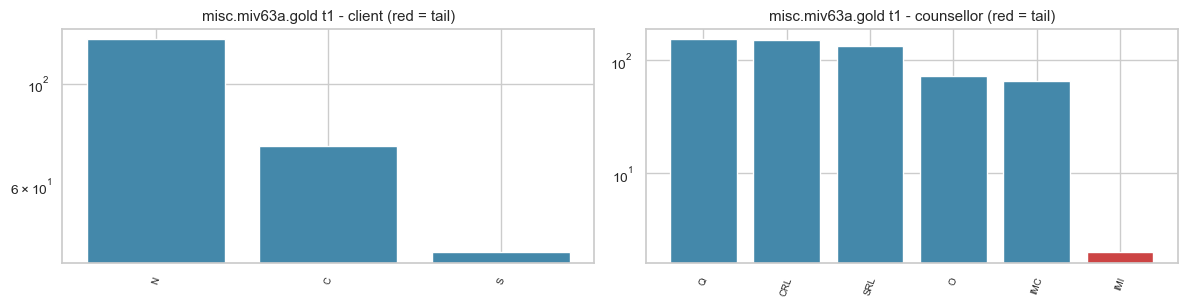

t1: tail codes = {'counsellor': ['IMI']}


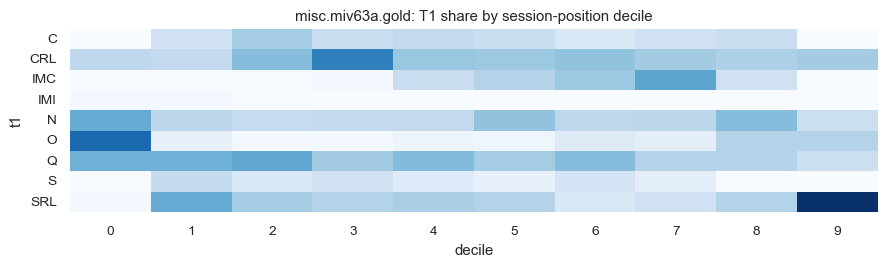

In [17]:
eda('misc.miv63a.gold', col_native=False)

### 6.2 `misc.hlqc.gold`: HLQC balanced MISC (TRAIN)

##### misc.hlqc.gold


,misc.hlqc.gold
conversations,10
rows (units),1925
counsellor rows,1040
client rows,885
units / conv (median),228.0
units / conv (min-max),35-318
turns / conv (median),89.5
words / unit (median),8.0
words / unit (p95),24.0
coded rows,1925


,text quality
has uppercase,0.425
has sentence punctuation,0.196
contains filler (um/uh/mm-hmm/you know),0.143
type-token ratio (5k-word sample),0.187


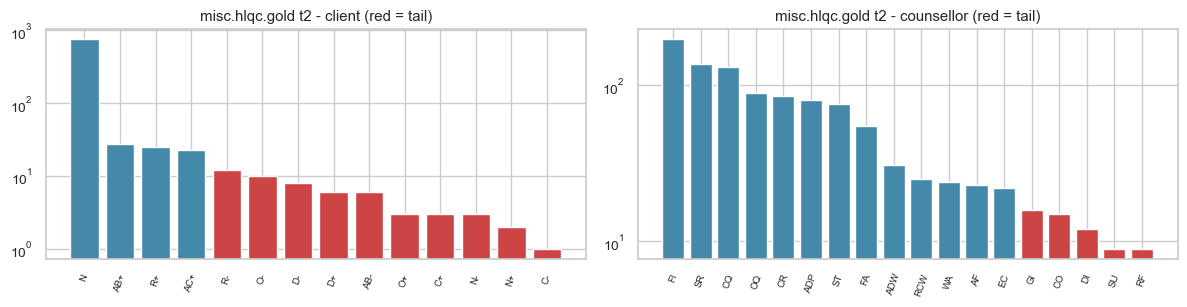

t2: tail codes = {'client': ['R-', 'O-', 'D-', 'D+', 'AB-', 'O+', 'C+', 'N-', 'N+', 'C-'], 'counsellor': ['GI', 'CO', 'DI', 'SU', 'RF']}


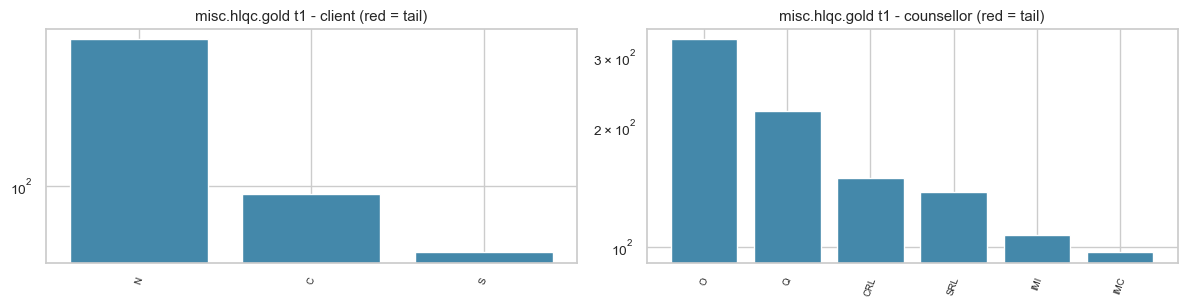

t1: tail codes = {}


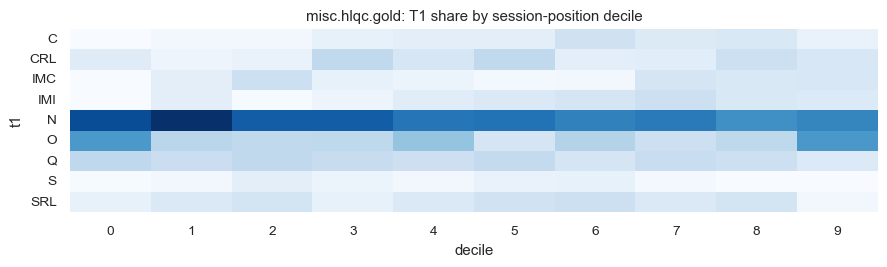

sessions: {'high_001': 35, 'high_099': 276, 'high_117': 173, 'high_121': 318, 'high_127': 109, 'low_001': 227, 'low_026': 229, 'low_031': 260, 'low_033': 230, 'low_080': 68}


In [18]:
eda('misc.hlqc.gold', col_native=False)
print('sessions:', F['misc.hlqc.gold'].groupby('conv_id').size().to_dict())

### 6.3 `annomi.gold`: AnnoMI

##### annomi.gold


,annomi.gold
conversations,133
rows (units),9699
counsellor rows,4882
client rows,4817
units / conv (median),47.0
units / conv (min-max),6-598
turns / conv (median),47.0
words / unit (median),9.0
words / unit (p95),57.0
coded rows,9699


,text quality
has uppercase,0.962
has sentence punctuation,0.933
contains filler (um/uh/mm-hmm/you know),0.308
type-token ratio (5k-word sample),0.265


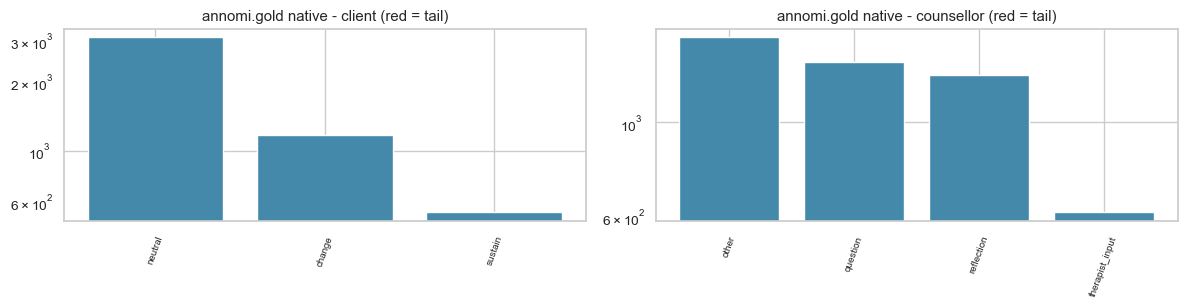

native: tail codes = {}


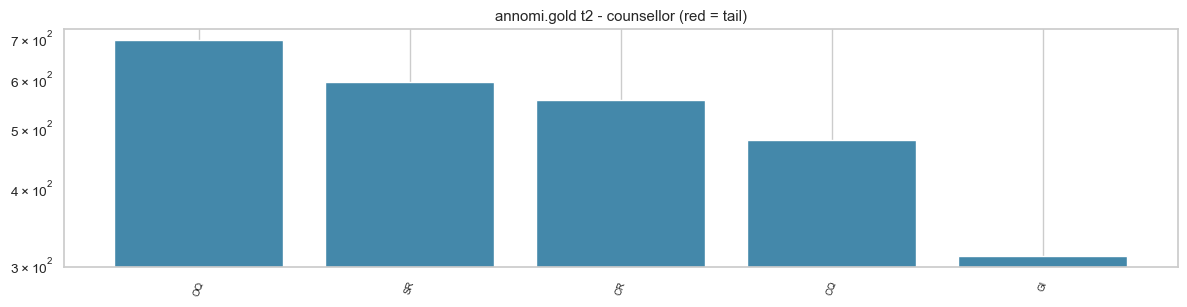

t2: tail codes = {}


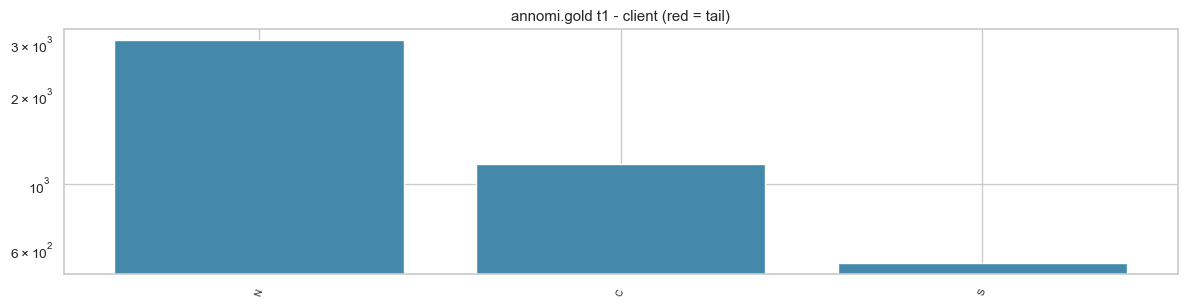

t1: tail codes = {}


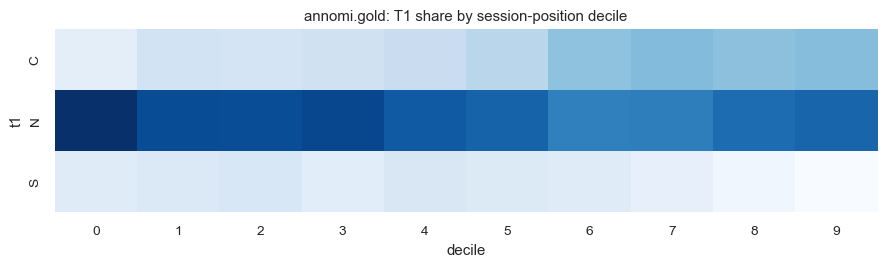

In [19]:
eda('annomi.gold')

,transcripts
quality,
high,110
low,23


,transcripts
topic,
reducing alcohol consumption,23
smoking cessation,19
taking medicine / following medical procedure,8
reducing recidivism,7
more exercise / increasing activity,7
reducing drug use,7
weight loss,6
unidentifiable,5
asthma management,5


,reflection_subtype,question_subtype,therapist_input_subtype
advice,0,0,145
closed,0,702,0
complex,695,0,0
information,0,0,455
negotiation,0,0,148
open,0,954,0
options,0,0,45
simple,849,0,0


Agreement on the 7 ten-rater transcripts: {'fleiss_main': 0.737, 'fleiss_client': 0.467, 'fleiss_reflection_subtype': 0.496, 'fleiss_question_subtype': 0.74, 'fleiss_therapist_input_subtype': 0.512}


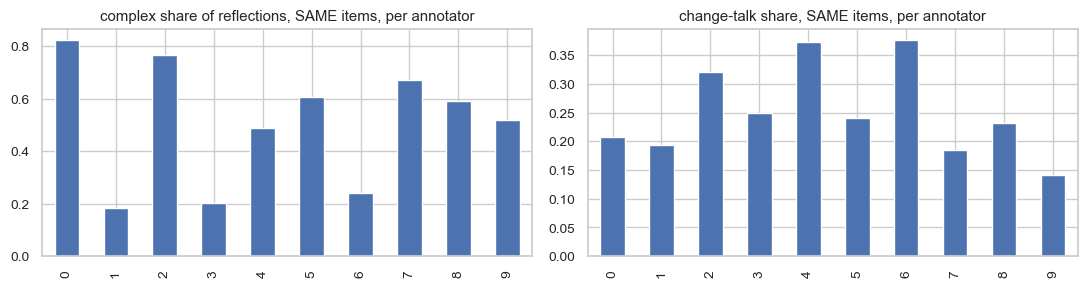

per-annotator kappa vs leave-one-out majority (main): {0: 0.79, 1: 0.831, 2: 0.809, 3: 0.649, 4: 0.845, 5: 0.827, 6: 0.85, 7: 0.812, 8: 0.85, 9: 0.85}
transcripts per annotator (single-annotated part): {0: 11, 1: 13, 2: 12, 3: 13, 4: 13, 5: 13, 6: 13, 7: 13, 8: 13, 9: 12}


In [20]:
an = F['annomi.gold']
sess = an.groupby('conv_id').agg(quality=('mi_quality','first'), topic=('topic','first'), n=('text','size'))
display(sess.quality.value_counts().to_frame('transcripts'))
display(sess.topic.value_counts().head(15).to_frame('transcripts'))
sub = an[an.speaker=='counsellor'][['reflection_subtype','question_subtype','therapist_input_subtype']].apply(lambda s: s.value_counts()).fillna(0).astype(int)
display(sub)
ag = registry.annomi_agreement()
print('Agreement on the 7 ten-rater transcripts:', {k: round(v, 3) for k, v in ag.items() if k.startswith('fleiss')})
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
pd.Series(ag['complex_share_same_items']).plot.bar(ax=ax[0], title='complex share of reflections, SAME items, per annotator')
pd.Series(ag['change_share_same_items']).plot.bar(ax=ax[1], title='change-talk share, SAME items, per annotator')
plt.tight_layout(); plt.show()
print('per-annotator kappa vs leave-one-out majority (main):', ag['loo_kappa_main'])
print('transcripts per annotator (single-annotated part):', an[an.n_annotators==1].groupby('annotator_id').conv_id.nunique().to_dict())

### 6.4 `welivita.gold`: Welivita & Pu forum MI

##### welivita.gold


,welivita.gold
conversations,2000
rows (units),20462
counsellor rows,17261
client rows,3201
units / conv (median),9.0
units / conv (min-max),2-48
turns / conv (median),2.5
words / unit (median),16.0
words / unit (p95),65.0
coded rows,16811


,text quality
has uppercase,0.962
has sentence punctuation,0.972
contains filler (um/uh/mm-hmm/you know),0.008
type-token ratio (5k-word sample),0.319


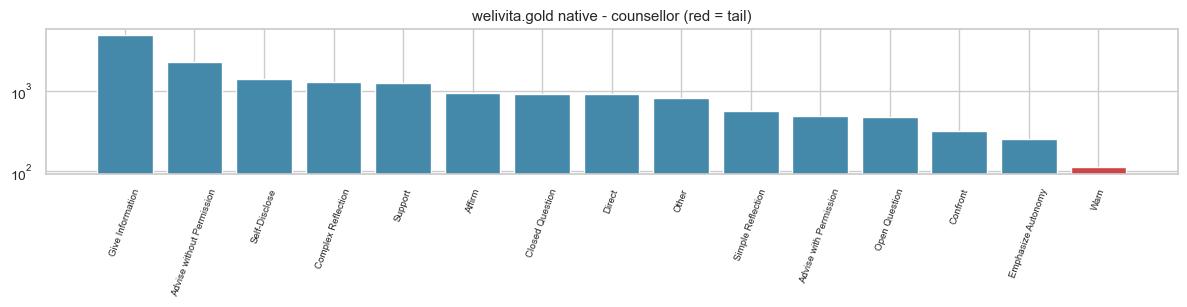

native: tail codes = {'counsellor': ['Warn']}


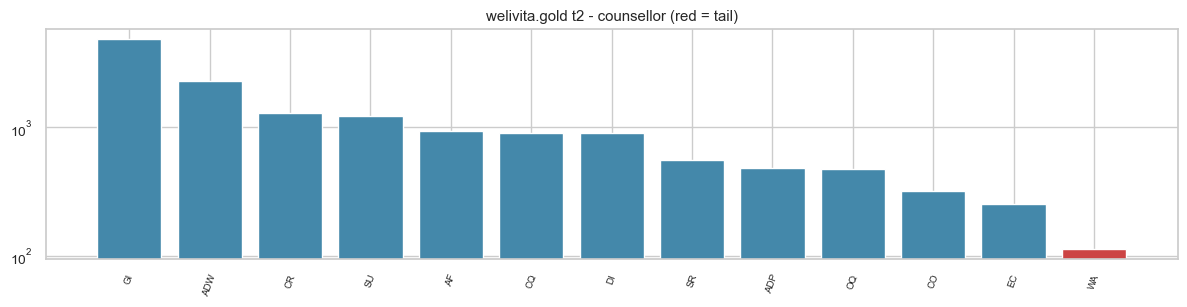

t2: tail codes = {'counsellor': ['WA']}
source: {'RED': 1000, 'counsel_chat': 1000}
agreement: {'n': 17261, 'raw_agreement': 0.41434447598632757, 'kappa': 0.3403646336038548, 'stage1_agreed': 7152}


stage-I agreed listener rows: 7152 of 17261


stage1_agreed,False,True,All
native,,,
All,9659,7152,16811
Give Information,2507,2349,4856
Advise without Permission,1460,825,2285
Self-Disclose,506,884,1390
Complex Reflection,1033,261,1294
Support,665,568,1233
Affirm,603,342,945
Closed Question,258,647,905
Direct,646,252,898


In [21]:
eda('welivita.gold')
w = F['welivita.gold']
print('source:', w.groupby('conv_id').source.first().value_counts().to_dict())
print('agreement:', registry.welivita_agreement())
lis = w[w.speaker=='counsellor']
print('stage-I agreed listener rows:', int(lis.stage1_agreed.sum()), 'of', len(lis))
display(pd.crosstab(lis.native, lis.stage1_agreed, margins=True).sort_values('All', ascending=False))

### 6.5 `miti.casaa.gold`: CASAA MITI 4 (aggregates only)

##### miti.casaa.gold


,miti.casaa.gold
conversations,20
rows (units),1346
counsellor rows,687
client rows,659
units / conv (median),76.0
units / conv (min-max),20-126
turns / conv (median),72.5
words / unit (median),17.0
words / unit (p95),81.0
coded rows,682


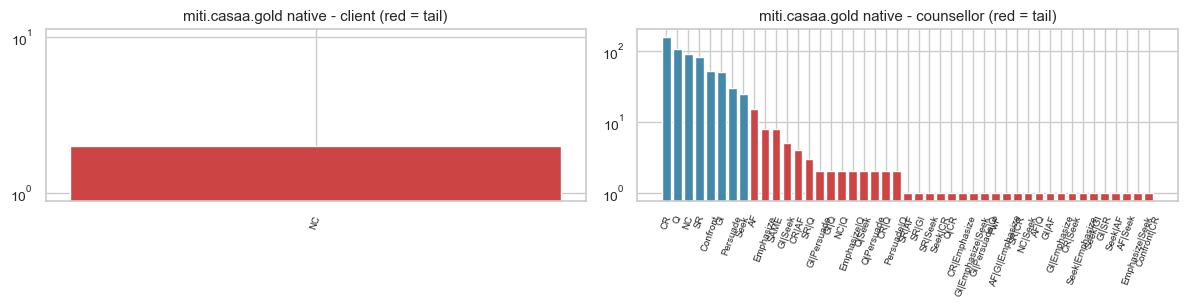

native: tail codes = {'client': ['NC'], 'counsellor': ['AF', 'SAME', 'Emphasize', 'GI|Seek', 'CR|AF', 'SR|Q', 'Persuade|Q', 'CR|Q', 'Q|Seek', 'Q|Persuade', 'GI|Persuade', 'Emphasize|Q', 'NC|Q', 'GI|Q', 'NC|Seek', 'Emphasize|Seek', 'AF|Seek', 'Seek|AF', 'GI|SR', 'Seek|GI', 'Seek|Emphasize', 'CR|Seek', 'GI|Emphasize', 'GI|AF', 'AF|Q', 'SR|AF', 'SR|CR', 'AF|GI|Emphasize', 'PwP', 'GI|Persuade|Q', 'GI|Emphasize|Seek', 'CR|Emphasize', 'Q|CR', 'Seek|CR', 'SR|Seek', 'SR|GI', 'Confront|CR']}


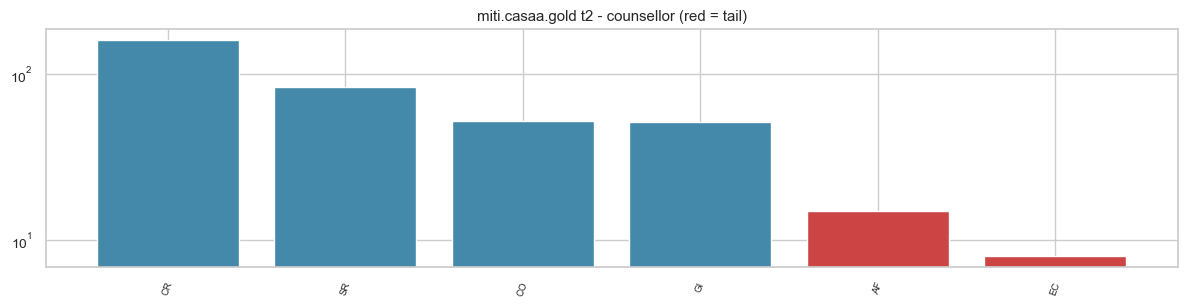

t2: tail codes = {'counsellor': ['AF', 'EC']}


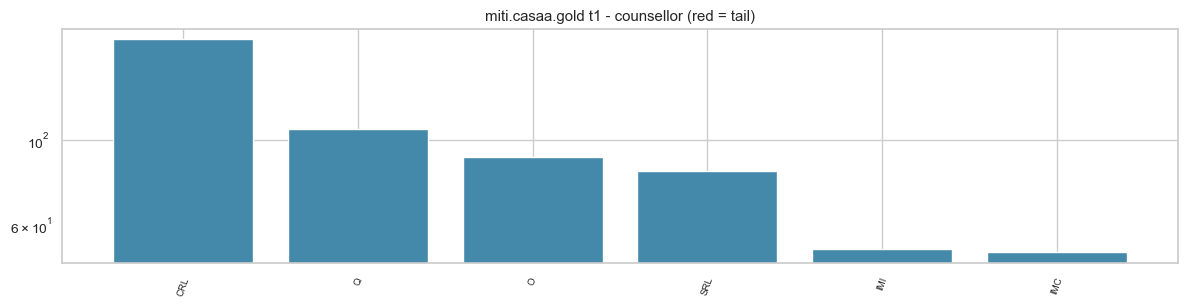

t1: tail codes = {}


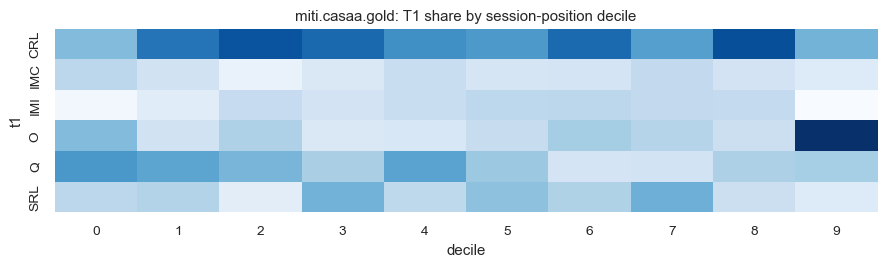

alignment of coded counsellor rows: {'turn': 598, 'multi': 50, 'sentence': 32}
HLQC-overlap sessions: ['casaa_emmys-first-encounter', 'casaa_rounder-miti-4']


,CCT,SST,PAR,EMP
conv_id,,,,
casaa_i-guess-i-dont-have-a-choice,1,4,1,1
casaa_maybe-hell-take-my-kids,2,2,2,2
casaa_should-i-really-be-honest,3,2,5,5
casaa_the-confirmed-smoker,4,4,5,5
casaa_session1miti,2,2,2,3
casaa_session2miti,2,1,1,2
casaa_session3miti,3,3,3,4
casaa_session4miti,4,3,3,3
casaa_session5miti,1,1,1,1


In [22]:
eda('miti.casaa.gold', text=False)
c = F['miti.casaa.gold']; cs = c[c.speaker=='counsellor']
print('alignment of coded counsellor rows:', cs['align'].value_counts().to_dict())
print('HLQC-overlap sessions:', sorted(c[c.hlqc_overlap.notna()].conv_id.unique()))
g = pd.read_csv('data/external/casaa/casaa_globals.csv'); display(g.set_index('conv_id'))

### 6.6 Unlabelled pools: `pool.hlqc`, `pool.miv63a`, `pool.miv63b`

In [23]:
for p in POOLS:
    display(pd.Series({**stats.structure(F[p]), **stats.text_quality(F[p])}, name=p).to_frame())
hq = F['pool.hlqc'].groupby('conv_id').size()
print('HLQC session-quality label:', pd.Series([c[:3] for c in hq.index]).value_counts().to_dict())
print('gold sessions inside their pools:',
      {g: f"{len(set(F[g].conv_id) & set(F[p].conv_id))}/{F[g].conv_id.nunique()}" for g, p in
       [('misc.hlqc.gold','pool.hlqc'), ('misc.miv63a.gold','pool.miv63a')]})

,pool.hlqc
conversations,257
rows (units),30610
counsellor rows,15898
client rows,14712
units / conv (median),97.0
units / conv (min-max),5-540
turns / conv (median),30.0
words / unit (median),8.0
words / unit (p95),23.0
coded rows,0


,pool.miv63a
conversations,173
rows (units),13692
counsellor rows,9835
client rows,3857
units / conv (median),76.0
units / conv (min-max),36-163
turns / conv (median),30.0
words / unit (median),12.0
words / unit (p95),25.0
coded rows,0


,pool.miv63b
conversations,165
rows (units),11771
counsellor rows,6844
client rows,4927
units / conv (median),69.0
units / conv (min-max),22-164
turns / conv (median),40.0
words / unit (median),12.0
words / unit (p95),26.0
coded rows,0


HLQC session-quality label: {'hig': 154, 'low': 103}
gold sessions inside their pools: {'misc.hlqc.gold': '10/10', 'misc.miv63a.gold': '10/10'}


In [24]:
o = registry.miv_outcomes('A')
cols = ['pre_importance','post_importance','week_later_importance','pre_confidence','post_confidence','week_later_confidence','pre_readiness','post_readiness','week_later_readiness']
display(o[cols].describe().T.round(2))
test = set(F['misc.miv63a.gold'].conv_id)
print('test sessions with outcomes:', o.conv_id.isin(test).sum(), '/ 10')
print('delta confidence, test vs rest:', o[o.conv_id.isin(test)].delta_confidence.mean().round(2), 'vs', o[~o.conv_id.isin(test)].delta_confidence.mean().round(2))

,count,mean,std,min,25%,50%,75%,max
pre_importance,173.0,6.20,2.48,0.0,4.0,7.0,8.0,10.0
post_importance,173.0,6.92,2.64,0.0,5.0,8.0,9.0,10.0
week_later_importance,159.0,6.74,2.55,0.0,5.0,7.0,9.0,10.0
pre_confidence,173.0,4.27,2.66,0.0,2.0,4.0,6.0,10.0
post_confidence,173.0,5.62,2.69,0.0,4.0,6.0,8.0,10.0
week_later_confidence,159.0,5.46,2.83,0.0,3.0,6.0,8.0,10.0
pre_readiness,173.0,5.86,2.67,0.0,4.0,6.0,8.0,10.0
post_readiness,173.0,6.54,2.64,0.0,5.0,7.0,9.0,10.0
week_later_readiness,159.0,6.13,2.84,0.0,4.0,7.0,8.0,10.0


test sessions with outcomes: 10 / 10
delta confidence, test vs rest: 1.9 vs 1.31


## 7. Cross-dataset comparison

In [25]:
summ = pd.DataFrame({k: {**stats.structure(v), **stats.text_quality(v)} for k, v in F.items()}).T
summ

,conversations,rows (units),counsellor rows,client rows,units / conv (median),units / conv (min-max),turns / conv (median),words / unit (median),words / unit (p95),coded rows,MISC T2 rows,MISC T1 rows,has uppercase,has sentence punctuation,contains filler (um/uh/mm-hmm/you know),type-token ratio (5k-word sample)
misc.miv63a.gold,10,821,580,241,78.5,37-119,32.5,12.0,25.0,821,821,821,0.847747,0.825822,0.003654,0.243
misc.hlqc.gold,10,1925,1040,885,228.0,35-318,89.5,8.0,24.0,1925,1925,1925,0.424935,0.195844,0.142857,0.187
pool.hlqc,257,30610,15898,14712,97.0,5-540,30.0,8.0,23.0,0,0,0,0.417543,0.098987,0.103953,0.202
pool.miv63a,173,13692,9835,3857,76.0,36-163,30.0,12.0,25.0,0,0,0,0.888037,0.812299,0.001461,0.251
pool.miv63b,165,11771,6844,4927,69.0,22-164,40.0,12.0,26.0,0,0,0,0.726531,0.63478,0.001189,0.254
annomi.gold,133,9699,4882,4817,47.0,6-598,47.0,9.0,57.0,9699,2628,4807,0.962367,0.932673,0.307867,0.265
welivita.gold,2000,20462,17261,3201,9.0,2-48,2.5,16.0,65.0,16811,14616,0,0.962418,0.972046,0.007624,0.319
miti.casaa.gold,20,1346,687,659,76.0,20-126,72.5,17.0,81.0,682,369,566,0.998514,0.907875,0.184993,0.235


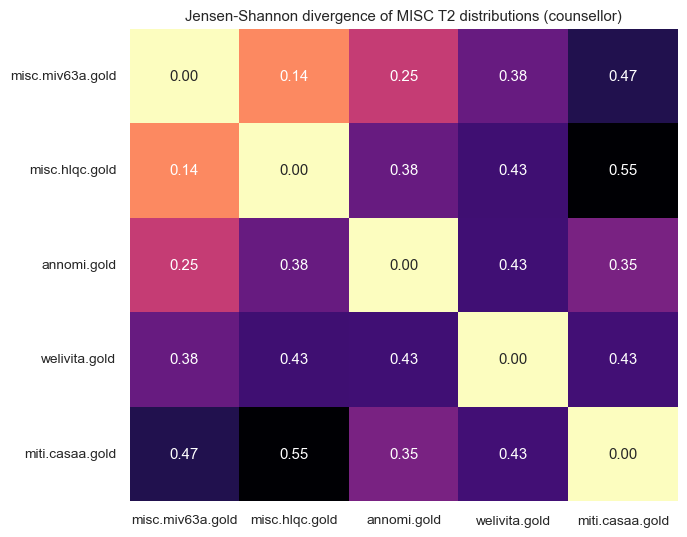

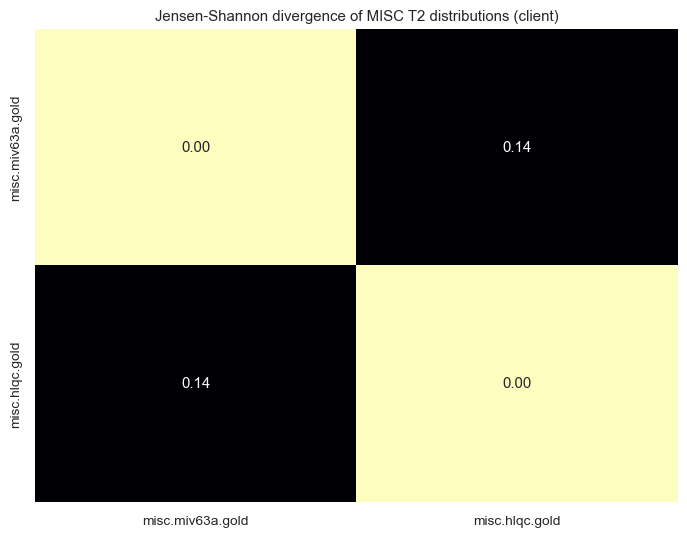

In [26]:
for spk in ['counsellor', 'client']:
    J = stats.js_matrix({k: F[k] for k in GOLD}, spk, 't2')
    plt.figure(figsize=(7, 5.5)); sns.heatmap(J, annot=True, fmt='.2f', cmap='magma_r', cbar=False)
    plt.title(f'Jensen-Shannon divergence of MISC T2 distributions ({spk})'); plt.tight_layout(); plt.show()

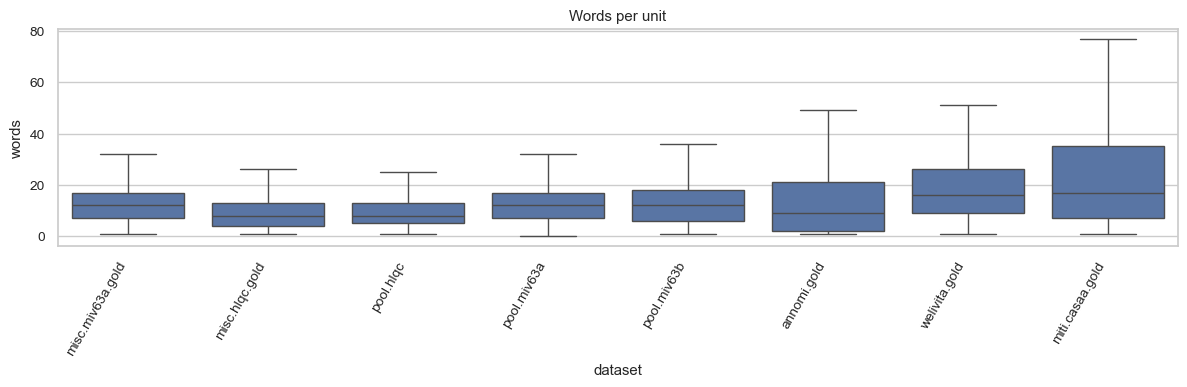

In [27]:
L = pd.concat([pd.DataFrame({'dataset': k, 'words': v.text.astype(str).str.split().str.len()}) for k, v in F.items()])
plt.figure(figsize=(12, 4)); sns.boxplot(data=L, x='dataset', y='words', showfliers=False)
plt.xticks(rotation=60, ha='right'); plt.title('Words per unit'); plt.tight_layout(); plt.show()

## 8. Split plan (`data/splits/*.json`, built by `python -m eda.splits`)
- **MISC main** (unchanged): train `misc.hlqc.gold`, test `misc.miv63a.gold`, dev = 5-fold HLQC CV, second test = CASAA minus HLQC duplicates.
- **AnnoMI own-scheme:** transcript-level, stratified; the 7 ten-rater transcripts are always test.
- **Welivita own-scheme:** dialogue-level, duplicate clusters kept together.
- **Pools:** exclusion lists.

(The synthetic manifest is covered in `synthetic_eda.ipynb`.)

In [28]:
MAN = {p.stem: json.load(open(p)) for p in sorted(Path('data/splits').glob('*.json')) if p.stem != 'synthetic'}
mm = MAN['misc_main']
print('MISC train:', mm['train']); print('MISC test:', {k: len(v) for k, v in mm['test'].items()})
print('Exclusions:')
for k, v in mm['exclude'].items():
    print(' ', k, '->', v)

MISC train: {'misc.hlqc.gold': ['high_001', 'high_099', 'high_117', 'high_121', 'high_127', 'low_001', 'low_026', 'low_031', 'low_033', 'low_080']}
MISC test: {'misc.miv63a.gold': 10, 'miti.casaa.gold (MISC-mapped)': 18}
Exclusions:
  annomi.gold (when the model also saw pool.hlqc: self-training/retrieval arms) -> ['2', '3', '8', '9', '15', '17', '19', '21', '23', '24', '27', '32', '33', '36', '40', '44', '50', '52', '53', '59', '65', '66', '68', '69', '72', '74', '80', '82', '87', '90', '91', '92', '97', '102', '103', '106', '107', '112', '113', '114', '115', '118', '119', '123', '126', '127', '130', '131']
  annomi.gold (when used as transfer test of HLQC-gold-trained models) -> ['15', '21', '44', '53']
  miti.casaa.gold -> ['casaa_emmys-first-encounter', 'casaa_rounder-miti-4']


In [29]:
def split_cov(ds, split_map, col):
    df = F[ds].copy(); df['split'] = df.conv_id.map(split_map)
    if ds == 'welivita.gold':
        df = df[(df.speaker != 'counsellor') | df.stage1_agreed]
    t = pd.crosstab([df.speaker, df[col]], df.split).fillna(0).astype(int)
    return t
a = MAN['annomi_own']['split']
print('AnnoMI transcripts per split:', pd.Series(a).value_counts().to_dict())
display(split_cov('annomi.gold', a, 'native'))
w = MAN['welivita_own']['split']
print('Welivita dialogues per split:', pd.Series(w).value_counts().to_dict())
display(split_cov('welivita.gold', w, 'native'))

AnnoMI transcripts per split: {'train': 91, 'dev': 22, 'test': 20}


split                       dev  test  train
speaker    native                           
client     change           340   120    714
           neutral          666   478   1958
           sustain          131    96    314
counsellor other            388   216    982
           question         306   216    864
           reflection       336   172    788
           therapist_input  115   100    399

Welivita dialogues per split: {'train': 1604, 'test': 200, 'dev': 196}


split                                 dev  test  train
speaker    native                                     
counsellor Advise with Permission       5     3     49
           Advise without Permission   74    95    656
           Affirm                      36    36    270
           Closed Question             55    65    527
           Complex Reflection          24    25    212
           Confront                     6    14     58
           Direct                      23    30    199
           Emphasize Autonomy           5     5     32
           Give Information           207   231   1911
           Open Question               29    31    302
           Other                       21    25    299
           Self-Disclose              101    81    702
           Simple Reflection           15    11    106
           Support                     54    52    462
           Warn                         1     1      6

In [30]:
pools = MAN['pools']
for p, v in pools.items():
    if not isinstance(v, dict): continue
    print(p, {k: (len(x) if isinstance(x, list) else x) for k, x in v.items() if k != 'notes'})

pool.hlqc {'exclude_always': 0, 'exclude_if_annomi_is_test': 63, 'exclude_if_casaa_is_test': 2, 'gold_sessions_and_their_copies': 16, 'redundant_duplicates': 45}
pool.miv63a {'exclude_always': 10}
pool.miv63b {'exclude_always': 0}


## 9. Checks (fail loudly if a number this catalogue depends on drifts)

In [31]:
assert len(F['misc.miv63a.gold']) == 821 and F['misc.miv63a.gold'].conv_id.nunique() == 10
assert len(F['misc.hlqc.gold']) == 1925 and F['misc.hlqc.gold'].conv_id.nunique() == 10
assert len(F['annomi.gold']) == 9699 and F['annomi.gold'].conv_id.nunique() == 133
assert len(F['welivita.gold']) == 20462
assert len(F['miti.casaa.gold']) == 1346
ag = registry.annomi_agreement(); wa = registry.welivita_agreement()
assert abs(ag['fleiss_main'] - 0.737) < 1e-3 and abs(ag['fleiss_client'] - 0.467) < 1e-3
assert abs(wa['kappa'] - 0.340) < 1e-3
pairs = set(zip(dup.conv_a, dup.conv_b)) | set(zip(dup.conv_b, dup.conv_a))
assert ('high_121', 'casaa_emmys-first-encounter') in pairs and ('high_072', 'casaa_rounder-miti-4') in pairs
assert splits.check(splits.build(F, P), F) == []
print('all checks passed')

all checks passed
